# COSC2753 Assignment 2 — Fashion Intelligence System
# Data Preprocessing (Tasks 1–3)

Single consolidated preprocessing pipeline for:
- **Task 1** — `articleType` classification
- **Task 2** — `season` classification
- **Task 3** — `gender` and `usage` classification

**Structure:**
1. Import libraries
2. Load dataset
3. Looking at `styles_train.csv` and the images
4. Train / validation split
5. EDA on the train split
6. Processing, and the processing decisions for each task
7. Utilities for the modelling notebooks

## 1. Import Libraries

In [1]:
import os
import json
import pickle
import hashlib
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.stats import chi2_contingency

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score

import torch
from torch.utils.data import Dataset, WeightedRandomSampler
import torchvision.transforms as T

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [2]:
DATA_DIR = Path("../data/raw/FashionDataset")

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(exist_ok=True)

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING'}] {p}")

[OK] ..\data\raw\FashionDataset\train\styles_train.csv
[OK] ..\data\raw\FashionDataset\train\images_train
[OK] ..\data\raw\FashionDataset\test\styles_prediction.csv
[OK] ..\data\raw\FashionDataset\test\images_test


## 3. Looking at `styles_train.csv` and the Images

### 3.1 First look at the CSV

In [3]:
df = pd.read_csv(TRAIN_CSV)
print(df.columns.tolist())
print(df.shape)
df.head(3)

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'Unnamed: 10', 'Unnamed: 11']
(38617, 12)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,NaN,NaN
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,NaN,NaN
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,NaN,NaN


In [4]:
# The raw CSV has stray commas in some rows, which pandas turns into extra
# 'Unnamed: N' columns. Drop them.
unnamed_cols = df.columns[df.columns.str.startswith('Unnamed')].tolist()
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print(f"Dropped {len(unnamed_cols)} malformed column(s): {unnamed_cols}")
print(df.columns.tolist())
print(df.shape)

Dropped 2 malformed column(s): ['Unnamed: 10', 'Unnamed: 11']
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']
(38617, 10)


### 3.2 Image ↔ CSV alignment (full dataset, before any split)

Checked here rather than after splitting, since a row with no matching image file can't be assigned to either split.

In [5]:
csv_ids = set(df['id'].astype(str))
disk_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob("*.jpg")}

missing_images = sorted(csv_ids - disk_ids)   # CSV rows with no image file
extra_images = sorted(disk_ids - csv_ids)     # image files with no CSV row

print(f"CSV rows with no image file: {len(missing_images)} -> {missing_images}")
print(f"Image files with no CSV row: {len(extra_images)}")

CSV rows with no image file: 5 -> ['12347', '39401', '39403', '39410', '39425']
Image files with no CSV row: 0


In [6]:
# Drop the unmatched rows now, before the split, so 'df' and its image folder
# stay aligned for every downstream step (EDA, split, processing).
df = df[~df['id'].astype(str).isin(missing_images)].reset_index(drop=True)
df['id'] = df['id'].astype(str).str.strip()
print(f"Remaining rows: {df.shape[0]}")

Remaining rows: 38612


### 3.3 Image integrity: corrupt files and exact duplicates

In [7]:
# Corrupt / unopenable images
corrupt = []
for img_id in df['id']:
    try:
        with Image.open(IMAGES_TRAIN_DIR / f"{img_id}.jpg") as im:
            im.verify()
    except Exception as e:
        corrupt.append((img_id, str(e)))

print(f"Corrupt/unopenable images: {len(corrupt)}")
for img_id, err in corrupt[:10]:
    print(f"  {img_id}: {err}")

Corrupt/unopenable images: 0


In [8]:
# Exact duplicate images (byte-for-byte, via md5 hash). The resulting 'dup_group'
# is needed later: it's what the train/val split is grouped on, so two copies of
# the same product photo can never end up on opposite sides of the split.
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_to_group = {}
group_ids = []
for img_id in df['id']:
    h = file_hash(IMAGES_TRAIN_DIR / f"{img_id}.jpg")
    if h not in hash_to_group:
        hash_to_group[h] = img_id       # first id seen becomes the group label
    group_ids.append(hash_to_group[h])

df['dup_group'] = group_ids
n_groups = df['dup_group'].nunique()
n_dupe_rows = len(df) - n_groups
print(f"{n_groups} unique image groups out of {len(df)} rows "
      f"({n_dupe_rows} rows are exact duplicates of another row)")

37849 unique image groups out of 38612 rows (763 rows are exact duplicates of another row)


### 3.4 Quick visual sanity check

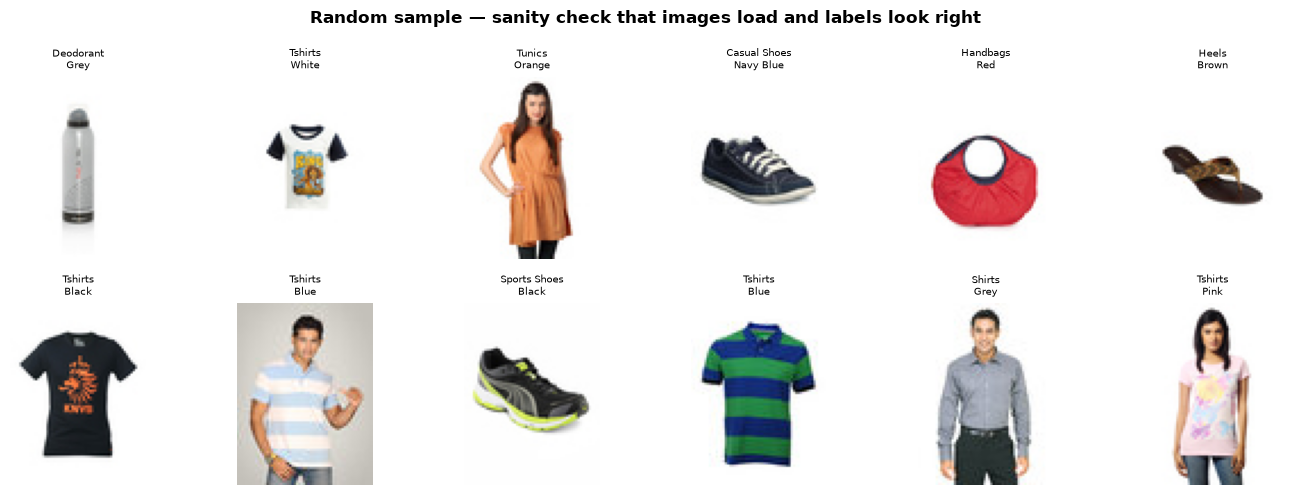

In [9]:
sample = df.sample(12, random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, (_, r) in zip(axes.flat, sample.iterrows()):
    ax.imshow(Image.open(IMAGES_TRAIN_DIR / f"{r['id']}.jpg"))
    ax.axis("off")
    ax.set_title(f"{r['articleType']}\n{r['baseColour']}", fontsize=7)
fig.suptitle("Random sample — sanity check that images load and labels look right", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Train / Validation Split

**Why not a plain random split:** a plain `train_test_split` (i) isn't grouped, so the 763 exact-duplicate image pairs found above can land on both sides of the split — validation examples leaking into training; and (ii) isn't stratified, so rare `articleType` classes can end up missing from one side entirely.

**Decision:** one **`StratifiedGroupKFold`** holdout (~75/25) — stratified on `articleType` (grouped, see 4.1) and grouped on `dup_group`. We only take the first fold as a single train/val holdout, not for cross-validation: with ~29k rows this is large enough for a stable estimate, and 4-fold CV would multiply training cost 4× across four from-scratch CNNs — cost better spent on model development within the report's page/time budget.

### 4.1 Rare-class grouping for `articleType` (must happen before the split)

The stratifier needs a fixed, known set of classes to balance across train/val, so this has to be decided pre-split rather than after. Classes below the threshold are relabelled to `"Other"` rather than dropped, so no image data is lost — the model still sees them, just under a catch-all label. The threshold trades off number of classes kept vs. rows retained:

In [10]:
vc_full = df['articleType'].value_counts()
print(f"Total articleType classes: {len(vc_full)}")
print(f"Classes with fewer than 10 samples: {(vc_full < 10).sum()}")
print(f"Classes with fewer than 5 samples:  {(vc_full < 5).sum()}\n")

for thresh in [5, 10, 15, 20, 30, 50]:
    kept_classes = (vc_full >= thresh).sum()
    kept_rows = vc_full[vc_full >= thresh].sum()
    print(f"threshold={thresh:>3}: classes kept={kept_classes:>3}/{len(vc_full)}, "
          f"rows kept={kept_rows:>6} ({kept_rows/len(df)*100:.1f}% of data)")

Total articleType classes: 124
Classes with fewer than 10 samples: 32
Classes with fewer than 5 samples:  21

threshold=  5: classes kept=103/124, rows kept= 38566 (99.9% of data)
threshold= 10: classes kept= 92/124, rows kept= 38491 (99.7% of data)
threshold= 15: classes kept= 81/124, rows kept= 38357 (99.3% of data)
threshold= 20: classes kept= 76/124, rows kept= 38274 (99.1% of data)
threshold= 30: classes kept= 70/124, rows kept= 38126 (98.7% of data)
threshold= 50: classes kept= 59/124, rows kept= 37695 (97.6% of data)


In [11]:
ARTICLE_TYPE_MIN_COUNT = 20  # keeps most classes while dropping the near-unlearnable long tail

rare_classes = vc_full[vc_full < ARTICLE_TYPE_MIN_COUNT].index
df['articleType_grouped'] = df['articleType'].where(~df['articleType'].isin(rare_classes), 'Other')

print("Classes after grouping:", df['articleType_grouped'].nunique())
print("'Other' bucket size:", (df['articleType_grouped'] == 'Other').sum())

Classes after grouping: 77
'Other' bucket size: 338


### 4.2 Stratified, group-aware 75/25 split

In [12]:
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)  # 1 fold ~= 25%

train_idx, val_idx = next(sgkf.split(df, df['articleType_grouped'], groups=df['dup_group']))
train_data = df.iloc[train_idx].reset_index(drop=True)
val_data = df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {train_data.shape[0]}, Val: {val_data.shape[0]}")

# --- sanity checks ---
overlap = set(train_data['dup_group']) & set(val_data['dup_group'])
print(f"Duplicate-image groups appearing in BOTH splits: {len(overlap)} (should be 0)")

missing_classes = set(df['articleType_grouped'].unique()) - set(train_data['articleType_grouped'].unique())
print(f"articleType_grouped classes missing from train: {missing_classes if missing_classes else 'none'}")

Train: 28958, Val: 9654
Duplicate-image groups appearing in BOTH splits: 0 (should be 0)
articleType_grouped classes missing from train: none


## 5. EDA on the Train Split

Done on `train_data` only, post-split — per course instruction, and to avoid any decision below being informed by validation data.

### 5.1 Structure & overview

In [13]:
print(train_data.columns.tolist())
print(train_data.shape)
train_data.head()

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'dup_group', 'articleType_grouped']
(28958, 12)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,dup_group,articleType_grouped
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,1163,Tshirts
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,1164,Tshirts
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,1165,Tshirts
3,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,1526,Backpacks
4,1528,Men,Apparel,Topwear,Jackets,Black,Fall,2010,Sports,Puma Men Ferrari Black Fleece Jacket,1528,Jackets


In [14]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28958 entries, 0 to 28957
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id                   28958 non-null  str  
 1   gender               28958 non-null  str  
 2   masterCategory       28958 non-null  str  
 3   subCategory          28958 non-null  str  
 4   articleType          28958 non-null  str  
 5   baseColour           28945 non-null  str  
 6   season               28944 non-null  str  
 7   year                 28958 non-null  int64
 8   usage                28902 non-null  str  
 9   productDisplayName   28952 non-null  str  
 10  dup_group            28958 non-null  str  
 11  articleType_grouped  28958 non-null  str  
dtypes: int64(1), str(11)
memory usage: 2.7 MB


### 5.2 Missing values

In [15]:
missing = train_data.isnull().sum()
missing_pct = (missing / len(train_data)) * 100
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct.round(2)}).sort_values('missing', ascending=False)
missing_df

,missing,pct
usage,56,0.19
season,14,0.05
baseColour,13,0.04
productDisplayName,6,0.02
subCategory,0,0.00
masterCategory,0,0.00
gender,0,0.00
id,0,0.00
year,0,0.00
articleType,0,0.00


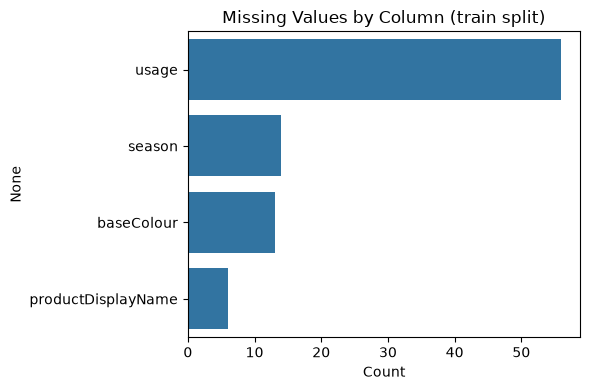

In [16]:
nonzero_missing = missing[missing > 0].sort_values(ascending=False)
if len(nonzero_missing):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=nonzero_missing.values, y=nonzero_missing.index)
    plt.title('Missing Values by Column (train split)')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

### 5.3 Duplicate rows (metadata-level)

In [17]:
print(f"Duplicate rows: {train_data.duplicated().sum()}")
print(f"Duplicate ids: {train_data['id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate ids: 0


### 5.4 Category distributions

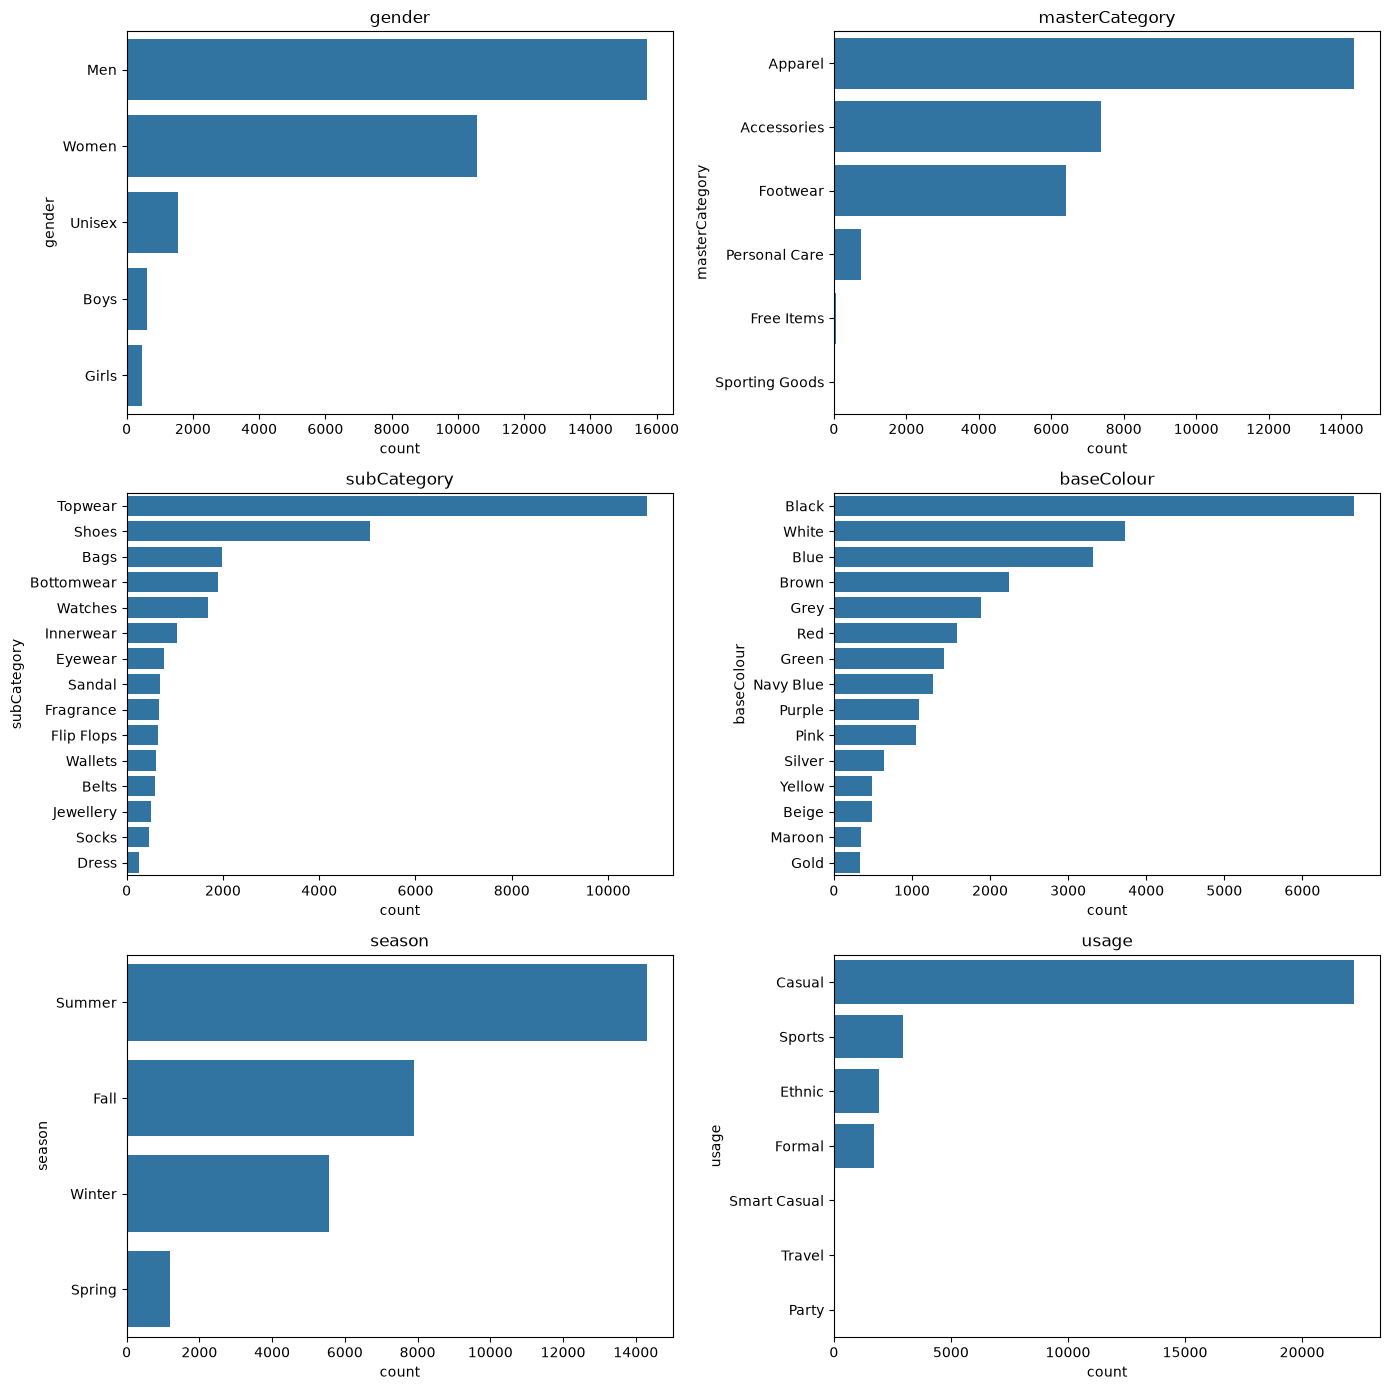

In [18]:
cat_cols = ['gender', 'masterCategory', 'subCategory', 'baseColour', 'season', 'usage']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, col in zip(axes.flatten(), cat_cols):
    order = train_data[col].value_counts().index[:15]  # top 15 to keep it readable
    sns.countplot(data=train_data, y=col, order=order, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [19]:
print("Category distributions (summary):\n")
for col in cat_cols + ['articleType']:
    vc = train_data[col].value_counts()
    top_val, top_count = vc.index[0], vc.iloc[0]
    top_pct = top_count / len(train_data) * 100
    n_classes = vc.shape[0]
    least_val, least_count = vc.index[-1], vc.iloc[-1]
    print(f"- {col}: {n_classes} categories. "
          f"Most common is '{top_val}' ({top_count} items, {top_pct:.1f}%). "
          f"Least common is '{least_val}' ({least_count} items).")

Category distributions (summary):

- gender: 5 categories. Most common is 'Men' (15702 items, 54.2%). Least common is 'Girls' (478 items).
- masterCategory: 6 categories. Most common is 'Apparel' (14355 items, 49.6%). Least common is 'Sporting Goods' (21 items).
- subCategory: 40 categories. Most common is 'Topwear' (10803 items, 37.3%). Least common is 'Vouchers' (1 items).
- baseColour: 46 categories. Most common is 'Black' (6661 items, 23.0%). Least common is 'Rose' (1 items).
- season: 4 categories. Most common is 'Summer' (14301 items, 49.4%). Least common is 'Spring' (1184 items).
- usage: 7 categories. Most common is 'Casual' (22217 items, 76.7%). Least common is 'Party' (12 items).
- articleType: 121 categories. Most common is 'Tshirts' (5085 items, 17.6%). Least common is 'Lounge Tshirts' (1 items).


### 5.5 `articleType` long-tail (separated — too many classes for a normal count plot)

In [20]:
vc = train_data['articleType'].value_counts()
print(f"Distinct articleType classes in train: {train_data['articleType'].nunique()}")
print(f"Classes with fewer than 10 samples: {(vc < 10).sum()}")
print(f"Classes with fewer than 5 samples:  {(vc < 5).sum()}")
vc.head(15)

Distinct articleType classes in train: 121
Classes with fewer than 10 samples: 35
Classes with fewer than 5 samples:  22


articleType
Tshirts         5085
Shirts          2315
Casual Shoes    2012
Watches         1689
Sports Shoes    1493
Tops            1211
Kurtas          1167
Handbags        1079
Heels            786
Sunglasses       785
Sandals          649
Flip Flops       647
Wallets          622
Belts            597
Backpacks        533
Name: count, dtype: int64

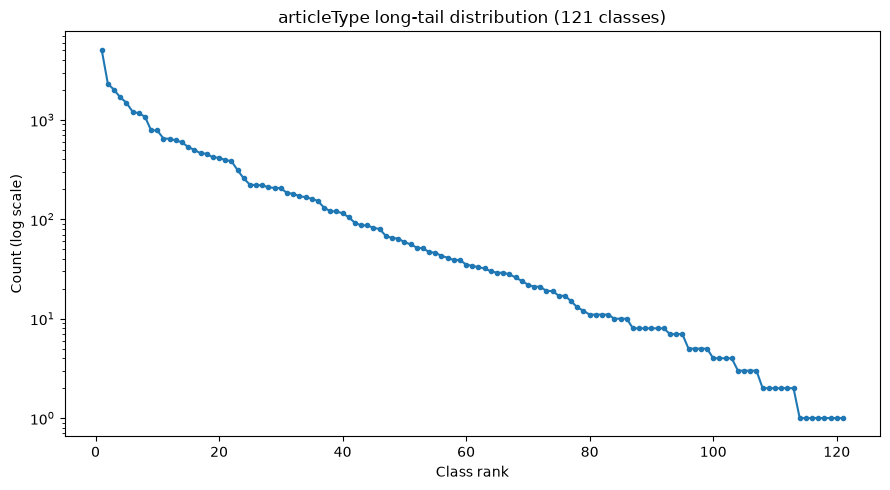

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(vc) + 1), vc.values, marker='o', markersize=3)
ax.set_yscale('log')
ax.set_xlabel('Class rank')
ax.set_ylabel('Count (log scale)')
ax.set_title(f'articleType long-tail distribution ({len(vc)} classes)')
plt.tight_layout()
plt.show()

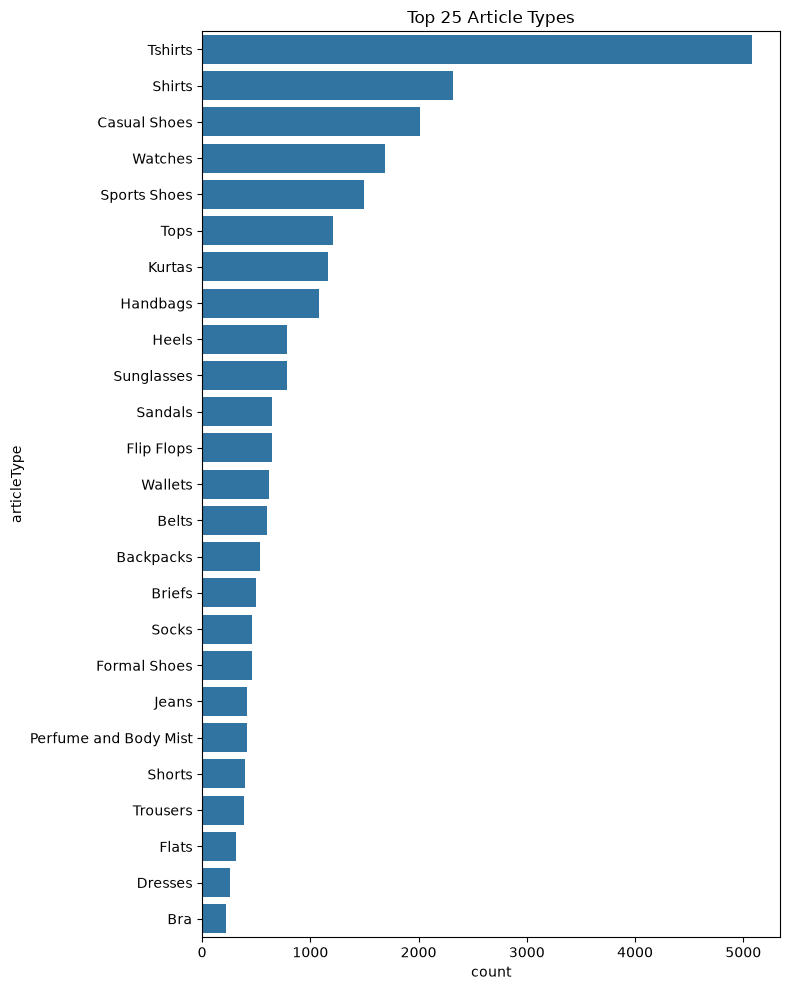

In [22]:
N = 25
plt.figure(figsize=(8, 10))
top_article = train_data['articleType'].value_counts().index[:N]
sns.countplot(data=train_data, y='articleType', order=top_article)
plt.title(f'Top {N} Article Types')
plt.tight_layout()
plt.show()

### 5.6 Year distribution & outliers

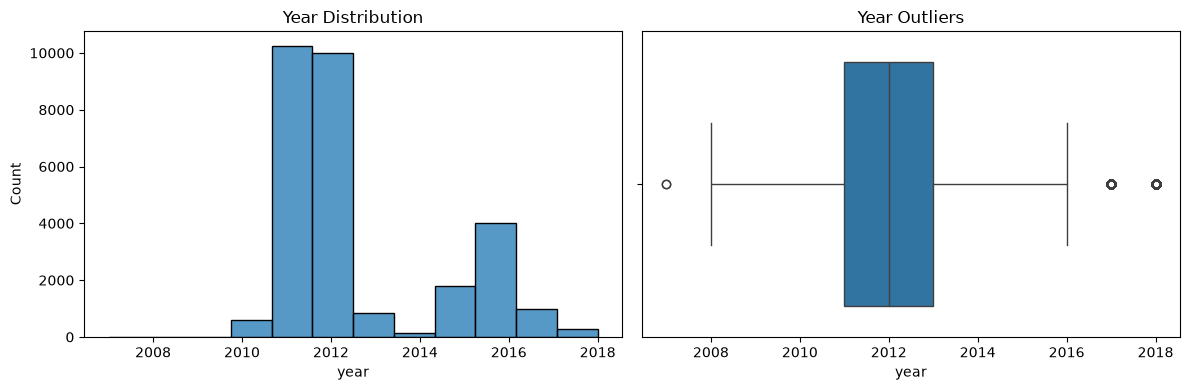

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_data['year'], bins=train_data['year'].nunique(), ax=axes[0])
axes[0].set_title('Year Distribution')
sns.boxplot(x=train_data['year'], ax=axes[1])
axes[1].set_title('Year Outliers')
plt.tight_layout()
plt.show()

In [24]:
year_counts = train_data['year'].value_counts().sort_index()

q1 = train_data['year'].quantile(0.25)
q3 = train_data['year'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_years = train_data[(train_data['year'] < lower_bound) | (train_data['year'] > upper_bound)]['year']
outlier_summary = outlier_years.value_counts().sort_index()

print(f"Data spans {train_data['year'].min():.0f} to {train_data['year'].max():.0f}.")
print(f"Most items are from {year_counts.idxmax():.0f} ({year_counts.max()} items).")
print(f"Outlier years (IQR rule): {outlier_summary.to_dict()}")

Data spans 2007 to 2018.
Most items are from 2011 (10248 items).
Outlier years (IQR rule): {2007: 2, 2017: 996, 2018: 293}


### 5.7 Cramér's V — association between categorical feature columns

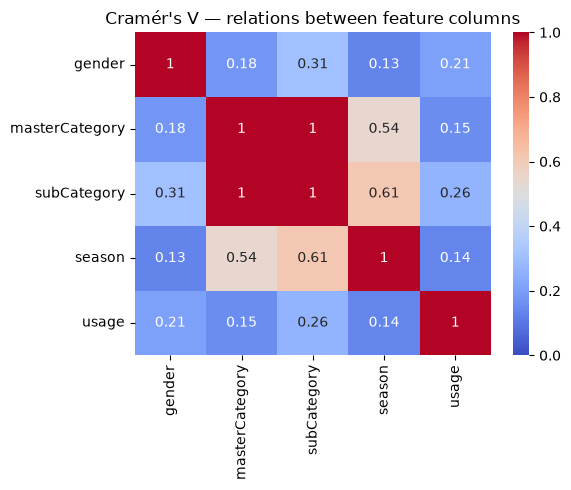

In [25]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

feature_cols = ['gender', 'masterCategory', 'subCategory', 'season', 'usage']
corr_matrix = pd.DataFrame(index=feature_cols, columns=feature_cols, dtype=float)
for c1, c2 in combinations(feature_cols, 2):
    v = cramers_v(train_data[c1], train_data[c2])
    corr_matrix.loc[c1, c2] = v
    corr_matrix.loc[c2, c1] = v
for c in feature_cols:
    corr_matrix.loc[c, c] = 1.0

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V — relations between feature columns")
plt.tight_layout()
plt.show()

### 5.8 Target distributions & relationships between targets

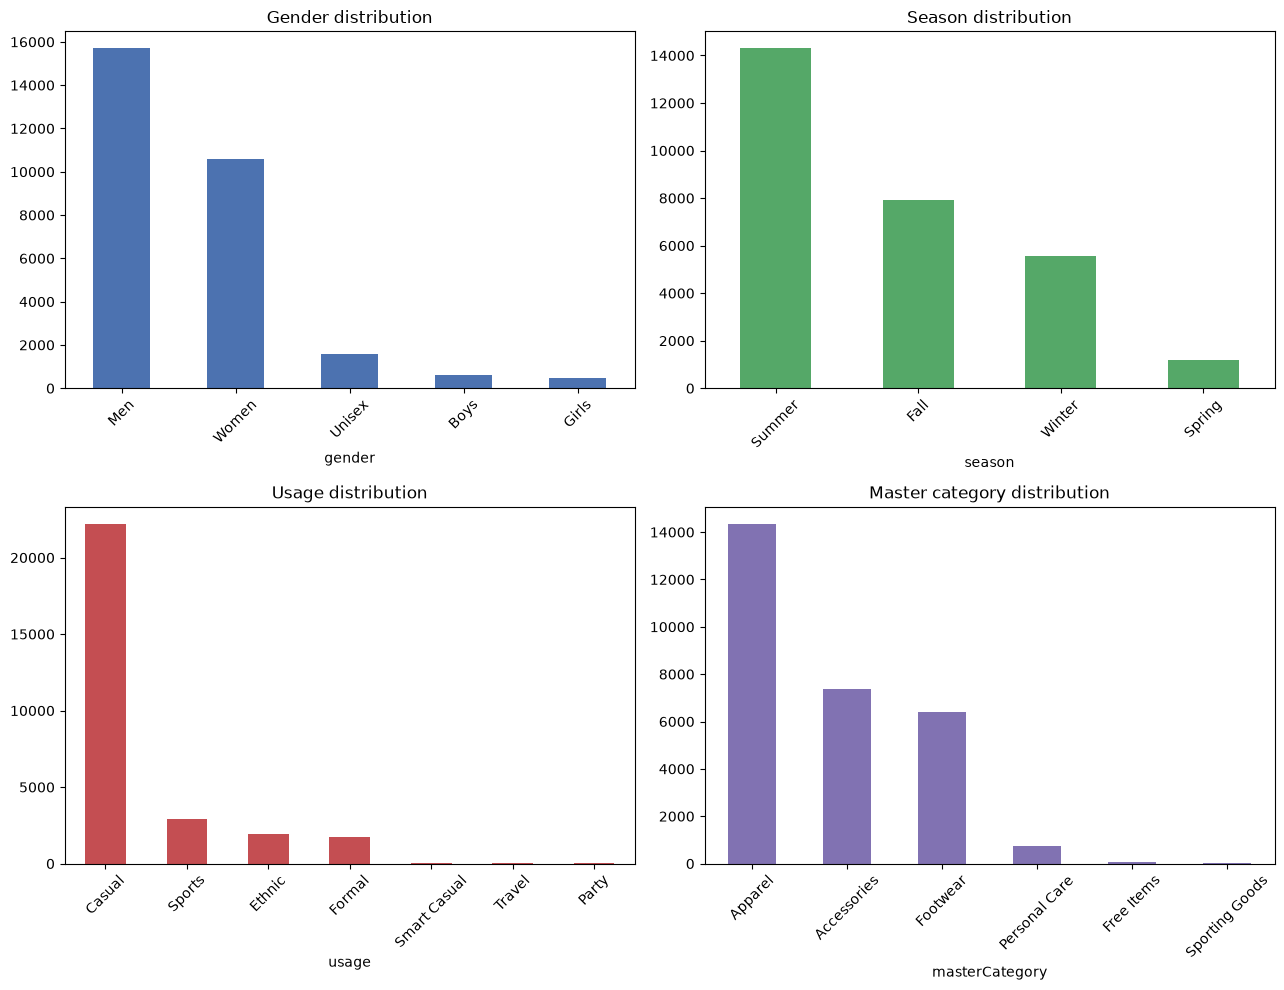

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

train_data['gender'].value_counts().plot(kind='bar', ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Gender distribution')
axes[0, 0].tick_params(axis='x', rotation=45)

train_data['season'].value_counts().plot(kind='bar', ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Season distribution')
axes[0, 1].tick_params(axis='x', rotation=45)

train_data['usage'].value_counts().plot(kind='bar', ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Usage distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

train_data['masterCategory'].value_counts().plot(kind='bar', ax=axes[1, 1], color='#8172B2')
axes[1, 1].set_title('Master category distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

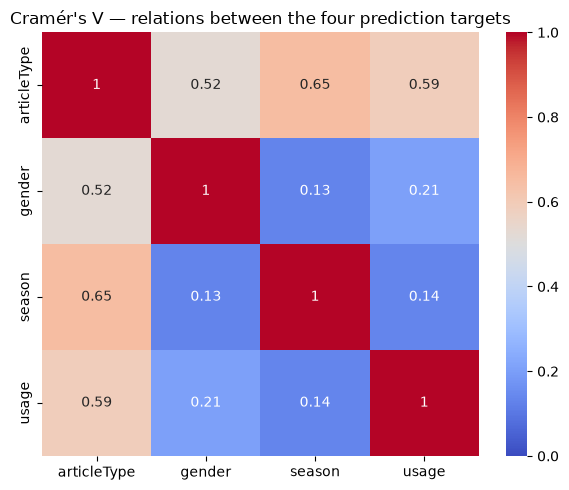

In [27]:
targets = ['articleType', 'gender', 'season', 'usage']

target_corr = pd.DataFrame(index=targets, columns=targets, dtype=float)
for c1, c2 in combinations(targets, 2):
    v = cramers_v(train_data[c1], train_data[c2])
    target_corr.loc[c1, c2] = v
    target_corr.loc[c2, c1] = v
for c in targets:
    target_corr.loc[c, c] = 1.0

plt.figure(figsize=(6, 5))
sns.heatmap(target_corr.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V — relations between the four prediction targets")
plt.tight_layout()
plt.show()

Strongest target relationship: articleType vs season (Cramér's V = 0.65)


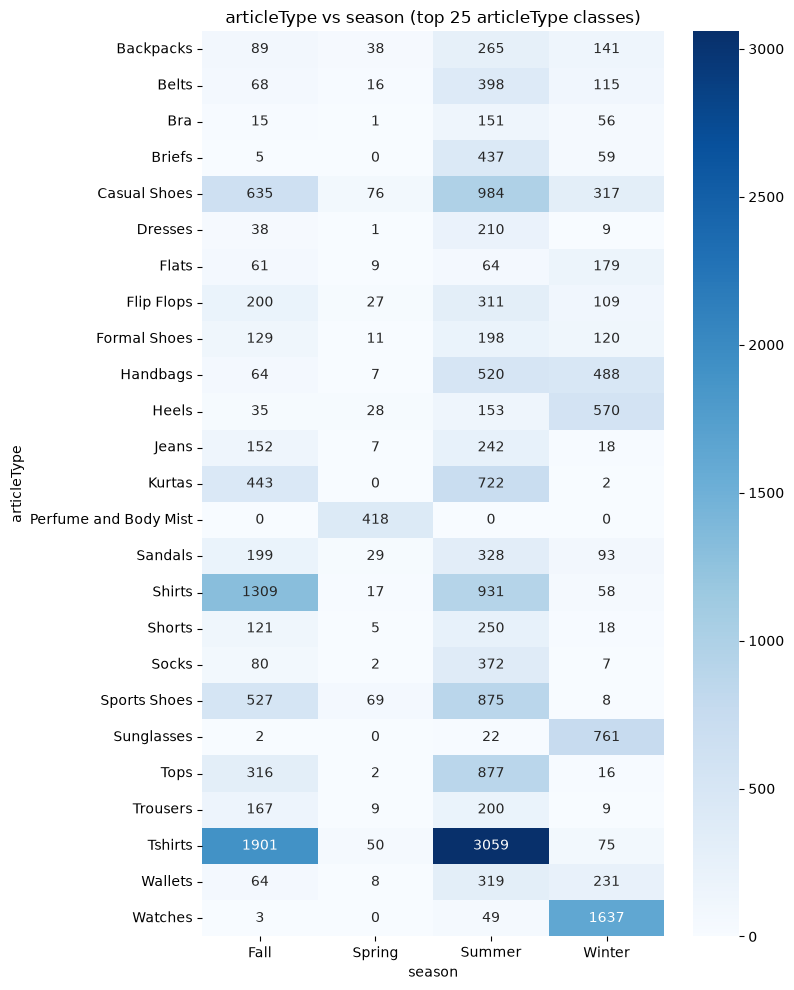

In [28]:
# The strongest target-target relationship, viewed as a crosstab heatmap
strongest_pair = target_corr.where(~np.eye(len(targets), dtype=bool)).stack().idxmax()
c1, c2 = strongest_pair
print(f"Strongest target relationship: {c1} vs {c2} (Cramér's V = {target_corr.loc[c1, c2]:.2f})")

plt.figure(figsize=(8, 10))
ct = pd.crosstab(train_data[c1], train_data[c2])
top_types = train_data[c1].value_counts().index[:25]
sns.heatmap(ct.loc[ct.index.intersection(top_types)], annot=True, fmt='d', cmap='Blues')
plt.title(f'{c1} vs {c2} (top 25 {c1} classes)')
plt.tight_layout()
plt.show()

### 5.9 Quantifying class imbalance

In [29]:
def imbalance_summary(series, name):
    vc = series.dropna().value_counts()
    ratio = vc.max() / vc.min()
    return {
        'target': name,
        'n_classes': len(vc),
        'majority_class': vc.idxmax(),
        'majority_count': int(vc.max()),
        'minority_class': vc.idxmin(),
        'minority_count': int(vc.min()),
        'imbalance_ratio': round(ratio, 1),
    }

imbalance_table = pd.DataFrame([
    imbalance_summary(train_data['gender'], 'gender'),
    imbalance_summary(train_data['season'], 'season'),
    imbalance_summary(train_data['usage'], 'usage'),
    imbalance_summary(train_data['articleType'], 'articleType'),
])
imbalance_table

,target,n_classes,majority_class,majority_count,minority_class,minority_count,imbalance_ratio
0,gender,5,Men,15702,Girls,478,32.8
1,season,4,Summer,14301,Spring,1184,12.1
2,usage,7,Casual,22217,Party,12,1851.4
3,articleType,121,Tshirts,5085,Shoe Laces,1,5085.0


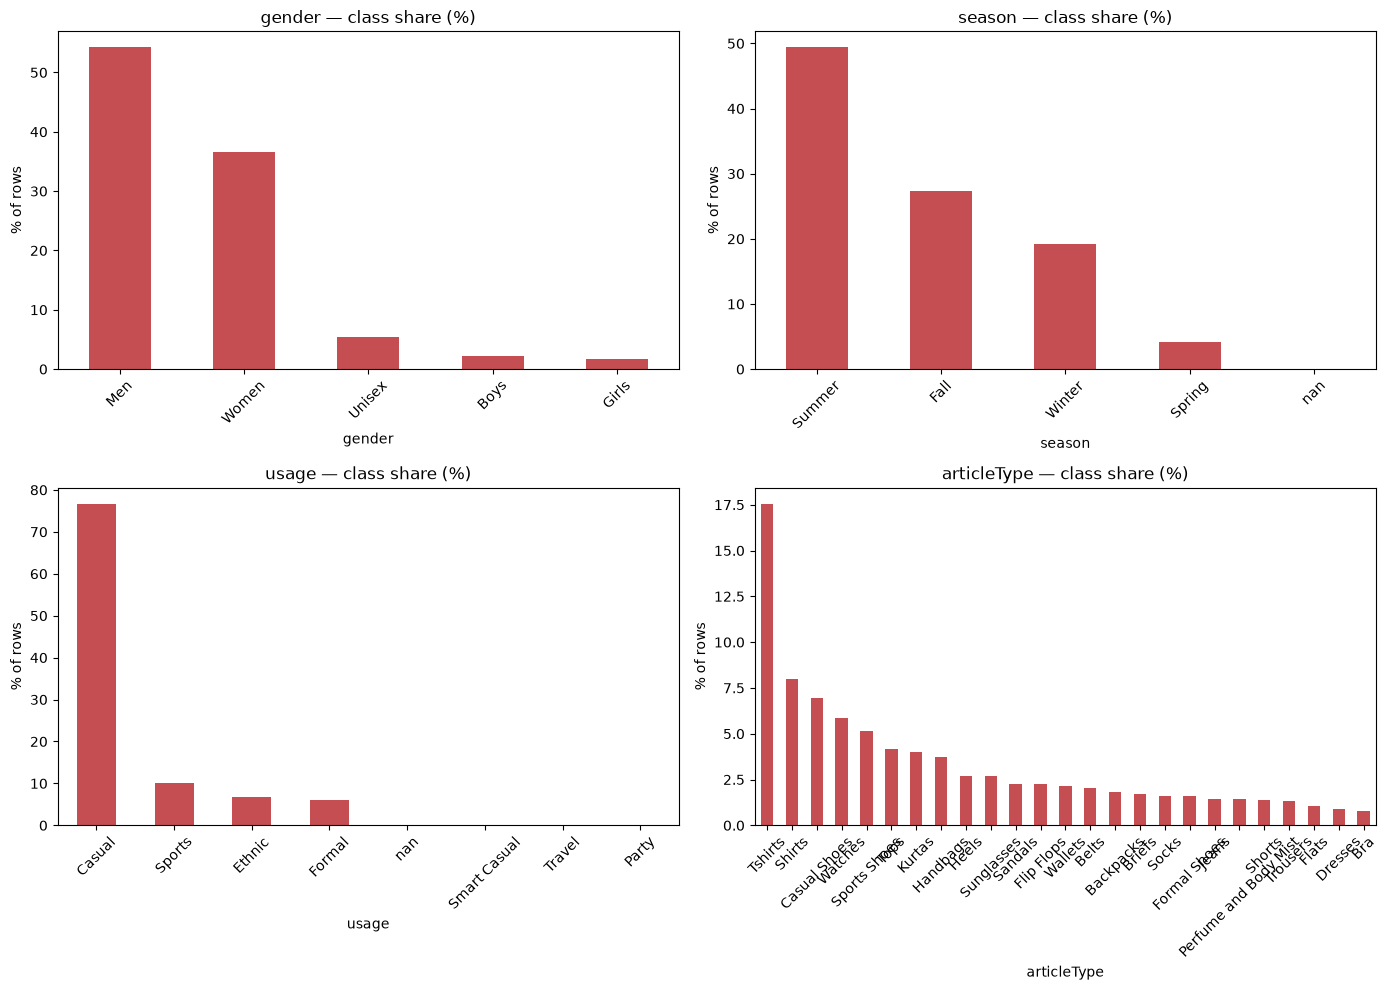

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['gender', 'season', 'usage', 'articleType']):
    shares = train_data[col].value_counts(normalize=True, dropna=False) * 100
    if col == 'articleType':
        shares = shares.head(25)
    shares.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_ylabel('% of rows')
    ax.set_title(f'{col} — class share (%)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5.10 Image profiling (dimensions, colour mode, file size) — train split only

In [31]:
def profile_images(ids, folder):
    rows = []
    for img_id in ids:
        p = folder / f"{img_id}.jpg"
        try:
            with Image.open(p) as im:      # reads header only, fast
                w, h, mode = im.size[0], im.size[1], im.mode
        except Exception:
            w = h = None
            mode = "ERR"
        rows.append({"id": img_id, "w": w, "h": h, "mode": mode,
                     "kb": round(p.stat().st_size / 1024, 2)})
    return pd.DataFrame(rows)

imgs_train = profile_images(train_data['id'], IMAGES_TRAIN_DIR)
print("Most common dimensions (train):")
print(imgs_train.groupby(['w', 'h']).size().sort_values(ascending=False).head())
print("\nColour mode counts (train):", imgs_train['mode'].value_counts().to_dict())

Most common dimensions (train):
w   h 
60  80    28946
53  80        6
60  60        4
    76        1
    77        1
dtype: int64

Colour mode counts (train): {'RGB': 28689, 'L': 269}


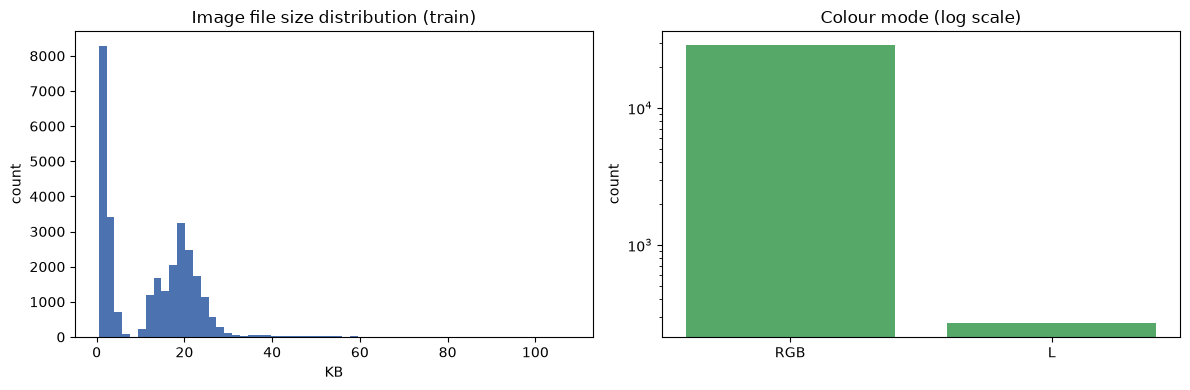

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(imgs_train["kb"], bins=60, color="#4C72B0")
ax[0].set(title="Image file size distribution (train)", xlabel="KB", ylabel="count")

mode_counts = imgs_train["mode"].value_counts()
ax[1].bar(mode_counts.index.astype(str), mode_counts.values, color="#55A868")
ax[1].set_yscale("log")
ax[1].set(title="Colour mode (log scale)", ylabel="count")
plt.tight_layout()
plt.show()

**EDA summary:**
- ~38.6k training images, mostly a consistent 60×80px, minor size outliers.
- Grayscale (`L`) images are a small minority — need RGB conversion before feeding a CNN (handled in the transform pipeline, §6.7).
- File sizes are mostly small (<25 KB) with a light long tail — no corrupted-looking files.
- `articleType` has a severe long tail (many classes with <10 samples) — addressed via rare-class grouping (§4.1, §6.3).
- `usage` is dominated by `Casual`; `gender` is dominated by `Men`/`Women` — both addressed via the imbalance-handling decision in §6.6.
- Feature/target Cramér's V values are generally weak-to-moderate — no pair of columns is redundant enough to drop.

## 6. Processing — and the Processing Decisions for Each Task

This section builds the four per-task datasets (`articleType`, `season`, `gender`, `usage`) that Tasks 1–3 train on, and documents the reasoning behind each processing decision.

### 6.1 Basic cleaning

Applied identically to `train_data` and `val_data` — no fitting involved, so there's no leakage risk in sharing one function across both splits.

In [33]:
def clean_dataframe(data):
    """Whitespace-strip categorical/text columns, coerce year to numeric,
    and fill non-target missing values with a placeholder. Fit-free — safe
    to reuse on train, val, or a future test split."""
    data = data.copy()

    cat_cols = ['gender', 'masterCategory', 'subCategory', 'articleType', 'articleType_grouped',
                'baseColour', 'season', 'usage', 'productDisplayName']
    for c in cat_cols:
        if c in data.columns:
            data[c] = data[c].astype('string').str.strip()

    if 'year' in data.columns:
        data['year'] = pd.to_numeric(data['year'], errors='coerce')

    # baseColour / productDisplayName aren't prediction targets, so missing values
    # here don't block any task — fill rather than drop.
    for c in ['baseColour', 'productDisplayName']:
        if c in data.columns:
            data[c] = data[c].fillna('Unknown')

    return data

train_data = clean_dataframe(train_data)
val_data = clean_dataframe(val_data)

print("Missing values after cleaning (train):")
print(train_data.isnull().sum())
print("\nMissing values after cleaning (val):")
print(val_data.isnull().sum())

Missing values after cleaning (train):
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour              0
season                 14
year                    0
usage                  56
productDisplayName      0
dup_group               0
articleType_grouped     0
dtype: int64

Missing values after cleaning (val):
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour              0
season                  6
year                    0
usage                  16
productDisplayName      0
dup_group               0
articleType_grouped     0
dtype: int64


### 6.2 Missing-value decision, per task

`season` and `usage` are themselves prediction targets — a missing value there can't be imputed without inventing a label, so those rows are dropped **per-task only**, not from the shared `train_data`/`val_data`. `articleType` (§4.1) and `gender` have no missing values. This is implemented via the per-task usable subsets built in §6.4.

### 6.3 Rare-class handling, per task

**`articleType`** — already grouped pre-split (§4.1, threshold = 20 samples) so the stratified split could see a fixed set of classes.

**`usage`** — has one class (`Home`) with essentially a single sample dataset-wide; a class that rare can't be split into train/val at all. Same logic as `articleType`, applied here:

In [34]:
USAGE_MIN_COUNT = 100

vc_usage = train_data['usage'].value_counts()
for thresh in [10, 25, 50, 100, 150]:
    kept_classes = (vc_usage >= thresh).sum()
    kept_rows = vc_usage[vc_usage >= thresh].sum()
    print(f"threshold={thresh:>3}: classes kept={kept_classes}/{len(vc_usage)}, "
          f"rows kept={kept_rows} ({kept_rows/train_data['usage'].notna().sum()*100:.1f}% of usage rows)")

threshold= 10: classes kept=7/7, rows kept=28902 (100.0% of usage rows)
threshold= 25: classes kept=5/7, rows kept=28871 (99.9% of usage rows)
threshold= 50: classes kept=4/7, rows kept=28831 (99.8% of usage rows)
threshold=100: classes kept=4/7, rows kept=28831 (99.8% of usage rows)
threshold=150: classes kept=4/7, rows kept=28831 (99.8% of usage rows)


In [35]:
rare_usage = vc_usage[vc_usage < USAGE_MIN_COUNT].index

for d in (train_data, val_data):
    d['usage_grouped'] = d['usage'].where(~d['usage'].isin(rare_usage), 'Other')

print("usage classes after grouping (train):", train_data['usage_grouped'].nunique())
print(train_data['usage_grouped'].value_counts())

usage classes after grouping (train): 5
usage_grouped
Casual    22217
Sports     2949
Ethnic     1934
Formal     1731
Other        71
Name: count, dtype: Int64


**`gender`** and **`season`** — no merging. `gender` has 5 classes and `season` has 4; both are imbalanced (see §5.9) but every class has enough samples to split, encode, and learn without collapsing categories.

### 6.4 Per-task usable subsets

In [36]:
# Column actually used as the prediction target for each task
target_columns = {
    'articleType': 'articleType_grouped',
    'season': 'season',
    'gender': 'gender',
    'usage': 'usage_grouped',
}

def usable_subset(data, target_col):
    return data[data[target_col].notna()].reset_index(drop=True)

train_usable = {t: usable_subset(train_data, col) for t, col in target_columns.items()}
val_usable = {t: usable_subset(val_data, col) for t, col in target_columns.items()}

for t in target_columns:
    print(f"{t}: train usable={len(train_usable[t])}, val usable={len(val_usable[t])}")

articleType: train usable=28958, val usable=9654
season: train usable=28944, val usable=9648
gender: train usable=28958, val usable=9654
usage: train usable=28902, val usable=9638


### 6.5 Label encoding

Fit on **train only**, per task (each task drops different rows, so a shared encoder across tasks isn't meaningful). Any val label an encoder has never seen — shouldn't happen after a stratified split, but checked anyway — is flagged and dropped rather than silently breaking `.transform()`.

In [37]:
encoders = {}
label_maps = {}

for t, col in target_columns.items():
    le = LabelEncoder()
    le.fit(train_usable[t][col])
    encoders[t] = le
    label_maps[t] = {i: c for i, c in enumerate(le.classes_)}

    train_usable[t][col + '_enc'] = le.transform(train_usable[t][col])

    val_known = val_usable[t][val_usable[t][col].isin(le.classes_)]
    dropped = len(val_usable[t]) - len(val_known)
    if dropped:
        print(f"WARNING: dropped {dropped} val rows for '{t}' — label(s) not seen in train")
    val_usable[t] = val_known.reset_index(drop=True)
    val_usable[t][col + '_enc'] = le.transform(val_usable[t][col])

    print(f"{t}: {len(le.classes_)} classes" + (f" -> {label_maps[t]}" if len(le.classes_) <= 6 else ""))

articleType: 77 classes
season: 4 classes -> {0: 'Fall', 1: 'Spring', 2: 'Summer', 3: 'Winter'}
gender: 5 classes -> {0: 'Boys', 1: 'Girls', 2: 'Men', 3: 'Unisex', 4: 'Women'}
usage: 5 classes -> {0: 'Casual', 1: 'Ethnic', 2: 'Formal', 3: 'Other', 4: 'Sports'}


### 6.6 Class imbalance — decision and implementation

**Considered:** loss-level class weighting, oversampling, and augmentation. Using all three risks over-correcting, so one consistent technique was picked across all four tasks rather than tuning per-task.

**Decision: `WeightedRandomSampler`**, paired with the augmentation pipeline built in §6.8. Built per task from **training rows only** (validation is never sampled, so it keeps reflecting the true distribution).

- **Why not loss-level class weights too:** once the sampler balances batches, adding loss weighting on top would double-penalize majority classes — risky for `articleType`, where inverse-frequency weights can go as low as ~0.01. Class weights are computed below for reference, but not used in training.
- **Why the sampler needs augmentation:** with `replacement=True`, rare classes get redrawn from the same small pool repeatedly — without variation this risks memorisation rather than generalisation. Augmentation (flip / rotation / colour jitter, §6.8) keeps repeated draws of rare-class images from being pixel-identical.
- **Deliberately not used: SMOTE** — interpolating pixels between unrelated product photos produces unrealistic images; augmentation is the image-domain equivalent.
- **Evaluation note:** track macro-F1 alongside accuracy in the modelling notebooks — accuracy alone is misleading here (e.g. a `usage` model predicting only `"Casual"` would score ~77% while being useless).

In [38]:
# Reference-only class weights (not used in the training loss)
class_weights = {}
for t, col in target_columns.items():
    data = train_usable[t]
    vc = data[col].value_counts().sort_index()
    n_classes, n_samples = len(vc), len(data)
    weights = n_samples / (n_classes * vc)
    weights = weights / weights.mean()
    ordered = [weights[c] for c in encoders[t].classes_]
    class_weights[t] = np.array(ordered)
    print(f"{t}: weight range {class_weights[t].min():.2f}-{class_weights[t].max():.2f}")

articleType: weight range 0.01-4.36
season: weight range 0.23-2.77
gender: weight range 0.07-2.33
usage: weight range 0.01-4.52


In [39]:
def get_weighted_sampler(data, target_col):
    """WeightedRandomSampler that oversamples minority classes within `data`.
    Call on the training subset only."""
    class_counts = data[target_col].value_counts()
    inv_freq = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = torch.tensor(data[target_col].map(inv_freq).values, dtype=torch.float32)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

samplers = {}
for t, col in target_columns.items():
    samplers[t] = get_weighted_sampler(train_usable[t], col)
    print(f"{t}: sampler built on {len(train_usable[t])} training rows")

articleType: sampler built on 28958 training rows
season: sampler built on 28944 training rows
gender: sampler built on 28958 training rows
usage: sampler built on 28902 training rows


### 6.7 Image size & normalization decision

**Size:** kept at the dataset's native **60×80** (width×height) rather than forced to a square — resizing to a square would distort every image's aspect ratio for no benefit, since 60×80 is already the near-universal size in the data (§5.10).

**Normalization:** per-channel mean/std computed from a random sample of train images, rather than a naive `/255` scale — this is standard practice for CNN training and centers the input distribution around 0, which naive `[0,1]` scaling doesn't.

In [40]:
IMG_WIDTH, IMG_HEIGHT = 60, 80

sample_ids = train_data['id'].sample(min(3000, len(train_data)), random_state=RANDOM_STATE)

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
n_pixels = 0

for img_id in sample_ids:
    img = Image.open(IMAGES_TRAIN_DIR / f"{img_id}.jpg").convert("RGB")
    arr = np.asarray(img, dtype=np.float64) / 255.0
    pixel_sum += arr.sum(axis=(0, 1))
    pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
    n_pixels += arr.shape[0] * arr.shape[1]

mean = pixel_sum / n_pixels
std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)

print(f"Computed mean (RGB): {mean.round(4)}")
print(f"Computed std (RGB):  {std.round(4)}")

Computed mean (RGB): [0.8493 0.8326 0.8273]
Computed std (RGB):  [0.2723 0.2838 0.2872]


### 6.8 Transform pipelines

In [41]:
# Base/eval pipeline — used for validation, test, and as the foundation of the
# training pipeline. Never augmented, so it stays a faithful evaluation signal.
base_transform = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),   # handles the grayscale files found in §5.10
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])
eval_transform = base_transform

# Training pipeline — adds mild, conservative augmentation. Kept conservative because
# these are catalog product photos, not natural scenes: a vertical flip or a large
# rotation would produce an unrealistic example (e.g. an upside-down shoe).
train_transform = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

print("Transforms ready: base_transform / eval_transform (no augmentation), train_transform (augmented)")

Transforms ready: base_transform / eval_transform (no augmentation), train_transform (augmented)


Augmentation isn't applied selectively to rare classes; it compounds naturally with the `WeightedRandomSampler` from §6.6 — since rare-class rows get redrawn more often, they also get re-augmented more often, which is exactly the extra visual variety they need.

### 6.9 PyTorch `Dataset` wrapper

In [42]:
class FashionImageDataset(Dataset):
    """Wraps a per-task dataframe (from train_usable / val_usable) with its images
    and label encoder. Pass `train_transform` for training data, `eval_transform`
    for validation/test data."""

    def __init__(self, dataframe, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.target_col_enc = target_col_enc
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        label = int(row[self.target_col_enc])
        return img, torch.tensor(label, dtype=torch.long)


# Example: build the four training datasets (validation datasets follow the same pattern
# with eval_transform and no sampler)
task_datasets = {
    t: FashionImageDataset(train_usable[t], IMAGES_TRAIN_DIR, col + '_enc', train_transform)
    for t, col in target_columns.items()
}
for t, ds in task_datasets.items():
    print(f"{t}: {len(ds)} training images")

articleType: 28958 training images
season: 28944 training images
gender: 28958 training images
usage: 28902 training images


### 6.10 Reproducibility configuration

Every threshold, seed, and decision made in this notebook, in one place — so a teammate (or a marker) can see what was decided without re-running all of the above.

In [43]:
config = {
    "random_state": RANDOM_STATE,
    "split": {
        "method": "single_stratified_group_holdout",
        "splitter": "StratifiedGroupKFold(n_splits=4), first split only",
        "validation_fraction": 0.25,
        "stratify_on": "articleType_grouped",
        "group_on": "dup_group (exact-duplicate images)",
    },
    "image": {
        "width": IMG_WIDTH,
        "height": IMG_HEIGHT,
        "normalization_mean": mean.tolist(),
        "normalization_std": std.tolist(),
    },
    "rare_class_thresholds": {
        "articleType": ARTICLE_TYPE_MIN_COUNT,
        "usage": USAGE_MIN_COUNT,
    },
    "class_counts": {t: int(len(encoders[t].classes_)) for t in target_columns},
    "imbalance_handling": "WeightedRandomSampler (train only) + augmentation; no loss-level class weighting",
    "missing_images_dropped": missing_images,
    "duplicate_image_pairs_found": len(df) - df['dup_group'].nunique(),
    "eda_scope": "train_data only, post-split, per course instruction",
}

with open(PROCESSED_DIR / 'pipeline_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))

{
  "random_state": 42,
  "split": {
    "method": "single_stratified_group_holdout",
    "splitter": "StratifiedGroupKFold(n_splits=4), first split only",
    "validation_fraction": 0.25,
    "stratify_on": "articleType_grouped",
    "group_on": "dup_group (exact-duplicate images)"
  },
  "image": {
    "width": 60,
    "height": 80,
    "normalization_mean": [
      0.8492654777331672,
      0.8326429887675832,
      0.8272526008430997
    ],
    "normalization_std": [
      0.2722692210898427,
      0.28384991651606145,
      0.28718284294608604
    ]
  },
  "rare_class_thresholds": {
    "articleType": 20,
    "usage": 100
  },
  "class_counts": {
    "articleType": 77,
    "season": 4,
    "gender": 5,
    "usage": 5
  },
  "imbalance_handling": "WeightedRandomSampler (train only) + augmentation; no loss-level class weighting",
  "missing_images_dropped": [
    "12347",
    "39401",
    "39403",
    "39410",
    "39425"
  ],
  "duplicate_image_pairs_found": 763,
  "eda_scope": "tr

### 6.11 Persist processed outputs

In [44]:
export_dir = PROCESSED_DIR / 'holdout_metadata'
export_dir.mkdir(parents=True, exist_ok=True)

for t in target_columns:
    train_usable[t].to_csv(export_dir / f'{t}_train.csv', index=False)
    val_usable[t].to_csv(export_dir / f'{t}_val.csv', index=False)
    print(f"{t}: exported {len(train_usable[t])} train and {len(val_usable[t])} validation rows")

with open(PROCESSED_DIR / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

mapping_dir = export_dir / 'label_mappings'
mapping_dir.mkdir(exist_ok=True)
for t, encoder in encoders.items():
    (mapping_dir / f'{t}.json').write_text(
        json.dumps({str(i): label for i, label in enumerate(encoder.classes_)}, indent=2),
        encoding='utf-8',
    )

# Full cleaned train/val (all columns, all rows) kept for reference
train_data.to_csv(PROCESSED_DIR / 'train_full.csv', index=False)
val_data.to_csv(PROCESSED_DIR / 'val_full.csv', index=False)

print("\nSaved to:", PROCESSED_DIR.resolve())

articleType: exported 28958 train and 9654 validation rows
season: exported 28944 train and 9648 validation rows
gender: exported 28958 train and 9654 validation rows
usage: exported 28902 train and 9637 validation rows

Saved to: D:\RMIT\ml_mas\COSC2753-Assignment-2\data\processed


### 6.12 Final validation — leakage checks and reload sanity check

In [45]:
# Leakage / integrity checks
# Checked against files on disk (not train_data ids) -- val ids are never a subset
# of train ids by design, since the split makes them disjoint on purpose.
train_image_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob('*.jpg')}

for t, col in target_columns.items():
    tr, va = train_usable[t], val_usable[t]
    assert set(tr['id']).isdisjoint(set(va['id'])), f"{t}: id overlap between train/val"
    assert set(tr['dup_group']).isdisjoint(set(va['dup_group'])), f"{t}: duplicate-image group overlap"
    assert tr[col].notna().all() and va[col].notna().all(), f"{t}: unexpected missing target"
    assert set(tr['id']).issubset(train_image_ids), f"{t}: train id(s) with no matching image file"
    assert set(va['id']).issubset(train_image_ids), f"{t}: val id(s) with no matching image file"

print("All leakage/integrity checks passed: no id or duplicate-image-group overlap between splits, "
      "no missing targets, all ids resolve to real images.")

All leakage/integrity checks passed: no id or duplicate-image-group overlap between splits, no missing targets, all ids resolve to real images.


In [46]:
# Reload sanity check — confirms what's on disk actually matches what's in memory
for t in target_columns:
    reloaded_train = pd.read_csv(export_dir / f'{t}_train.csv')
    reloaded_val = pd.read_csv(export_dir / f'{t}_val.csv')

    assert len(reloaded_train) == len(train_usable[t]), f"train row count mismatch for {t}"
    assert len(reloaded_val) == len(val_usable[t]), f"val row count mismatch for {t}"

    print(f"{t}: OK — train={len(reloaded_train)}, val={len(reloaded_val)}, "
          f"classes={reloaded_train[target_columns[t]].nunique()}")

with open(PROCESSED_DIR / 'label_encoders.pkl', 'rb') as f:
    reloaded_encoders = pickle.load(f)
print("Encoders reload OK:", list(reloaded_encoders.keys()))

articleType: OK — train=28958, val=9654, classes=77
season: OK — train=28944, val=9648, classes=4
gender: OK — train=28958, val=9654, classes=5
usage: OK — train=28902, val=9637, classes=5
Encoders reload OK: ['articleType', 'season', 'gender', 'usage']


## Task 2: Fashion season classification

In [47]:
# Reuse the Task 2-specific prepared splits. These already contain season_enc.
task2_train = train_usable['season'].copy()
task2_val = val_usable['season'].copy()

assert 'season_enc' in task2_train.columns
assert 'season_enc' in task2_val.columns
print(f'Task 2 train: {len(task2_train):,}; validation: {len(task2_val):,}')
print('Season classes:', encoders['season'].classes_.tolist())

Task 2 train: 28,944; validation: 9,648
Season classes: ['Fall', 'Spring', 'Summer', 'Winter']


In [48]:
print(task2_train.columns.tolist())

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'dup_group', 'articleType_grouped', 'usage_grouped', 'season_enc']


### a) Tabular data preprocessing

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import joblib

TASK2_TARGET = 'season'
TASK2_FEATURES = ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'year', 'usage']
TASK2_CATEGORICAL = [c for c in TASK2_FEATURES if c != 'year']
TASK2_NUM = ['year']

task2_train = usable_subset(task2_train, TASK2_TARGET)
task2_val = usable_subset(task2_val, TASK2_TARGET)
known_seasons = set(task2_train[TASK2_TARGET].unique())
task2_val = task2_val[task2_val[TASK2_TARGET].isin(known_seasons)].reset_index(drop=True)
X_train = task2_train[TASK2_FEATURES].copy()
X_val = task2_val[TASK2_FEATURES].copy()
# Convert pandas nullable values to NumPy-compatible missing values for sklearn.
for frame in (X_train, X_val):
    for col in TASK2_CATEGORICAL:
        frame[col] = frame[col].astype(object).where(frame[col].notna(), np.nan)
    frame['year'] = pd.to_numeric(frame['year'], errors='coerce')
y_train = task2_train['season_enc'].to_numpy()
y_val = task2_val['season_enc'].to_numpy()

In [50]:
preprocessor = ColumnTransformer([
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), TASK2_CATEGORICAL),

    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), TASK2_NUM)
])

# Fit on metadata from training data only; apply the fitted transform to validation data.
metadata_train = preprocessor.fit_transform(X_train)
metadata_val = preprocessor.transform(X_val)
print('Metadata train shape:', metadata_train.shape)
print('Metadata validation shape:', metadata_val.shape)
print('Encoded target shapes:', y_train.shape, y_val.shape)

Metadata train shape: (28944, 227)
Metadata validation shape: (9648, 227)
Encoded target shapes: (28944,) (9648,)


### b) Image models and multi-input model

The pretrained networks below are comparison baselines. The multi-input model learns an image encoder from the supplied training data and fuses its features with encoded metadata.

In [51]:
import copy
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torchvision.models import resnet18, ResNet18_Weights, mobilenet_v3_small, MobileNet_V3_Small_Weights
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE, EPOCHS, NUM_WORKERS = 64, 8, 0

# Metadata inputs are fit on training data only.
META_FEATURES = ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'year', 'usage']
META_CAT = [c for c in META_FEATURES if c != 'year']
META_NUM = ['year']
meta_preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), META_CAT),
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), META_NUM)
])
# Replace pandas nullable values before passing metadata to sklearn.
meta_train_frame = task2_train[META_FEATURES].copy()
meta_val_frame = task2_val[META_FEATURES].copy()
for frame in (meta_train_frame, meta_val_frame):
    for col in META_CAT:
        frame[col] = frame[col].astype(object).where(frame[col].notna(), np.nan)
    frame['year'] = pd.to_numeric(frame['year'], errors='coerce')
meta_train = meta_preprocessor.fit_transform(meta_train_frame).astype('float32')
meta_val = meta_preprocessor.transform(meta_val_frame).astype('float32')
season_encoder = LabelEncoder().fit(task2_train['season'])
y_train = season_encoder.transform(task2_train['season'])
y_val = season_encoder.transform(task2_val['season'])

class MultiInputDataset(Dataset):
    def __init__(self, frame, metadata, labels, image_dir, transform):
        self.frame, self.metadata, self.labels = frame.reset_index(drop=True), metadata, labels
        self.image_dir, self.transform = image_dir, transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            image = self.transform(im)
        return image, torch.tensor(self.metadata[i].toarray() if hasattr(self.metadata[i], 'toarray') else self.metadata[i], dtype=torch.float32).squeeze(0), torch.tensor(self.labels[i], dtype=torch.long)

# Build datasets and loaders for the multi-input model.
train_ds = MultiInputDataset(task2_train, meta_train, y_train, IMAGES_TRAIN_DIR, train_transform)
val_ds = MultiInputDataset(task2_val, meta_val, y_val, IMAGES_TRAIN_DIR, eval_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Create pretrained image-only comparison models and replace their classifiers for season prediction.
def make_pretrained(model_name):
    if model_name == 'resnet18':
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, len(season_encoder.classes_))
    else:
        model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, len(season_encoder.classes_))
    return model.to(DEVICE)

class MultiInputNet(nn.Module):
    def __init__(self, metadata_dim, n_classes, pretrained=None):
        super().__init__()
        self.image = resnet18(weights=None)
        
        image_dim = self.image.fc.in_features
        self.image.fc = nn.Identity()
        
        
        self.meta = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        
        self.head = nn.Sequential(
            nn.Linear(image_dim + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )

    def forward(self, image, metadata):
        img_feats = self.image(image)
        meta_feats = self.meta(metadata)
        fused = torch.cat([img_feats, meta_feats], dim=1)
        return self.head(fused)
    
# Train the multi-input model and retain the checkpoint with the best validation macro-F1.
def train_model(model):
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    best_state, best_f1 = None, -1
    for epoch in range(EPOCHS):
        model.train()
        for images, metadata, labels in tqdm(train_loader, desc=f'Multi-input train {epoch + 1}/{EPOCHS}'):
            optimiser.zero_grad(); logits = model(images.to(DEVICE), metadata.to(DEVICE)); loss = criterion(logits, labels.to(DEVICE)); loss.backward(); optimiser.step()
        model.eval(); preds, actual = [], []
        with torch.no_grad():
            for images, metadata, labels in tqdm(val_loader, desc=f'Multi-input val {epoch + 1}/{EPOCHS}', leave=False):
                preds.extend(model(images.to(DEVICE), metadata.to(DEVICE)).argmax(1).cpu().numpy()); actual.extend(labels.numpy())
        score = f1_score(actual, preds, average='macro')
        print(f'Epoch {epoch + 1}/{EPOCHS} - macro-F1: {score:.4f}')
        if score > best_f1: best_f1, best_state = score, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state); return model, best_f1

# Train an image-only model using the existing FashionImageDataset.
def train_image_only(model):
    loader_tr = DataLoader(FashionImageDataset(task2_train, IMAGES_TRAIN_DIR, 'season_enc', train_transform), batch_size=BATCH_SIZE, shuffle=True)
    loader_va = DataLoader(FashionImageDataset(task2_val, IMAGES_TRAIN_DIR, 'season_enc', eval_transform), batch_size=BATCH_SIZE)
    opt, criterion, best_state, best_f1 = torch.optim.AdamW(model.parameters(), lr=3e-4), nn.CrossEntropyLoss(), None, -1
    for epoch in range(EPOCHS):
        model.train()
        for images, labels in tqdm(loader_tr, desc=f'{model.__class__.__name__} train {epoch + 1}/{EPOCHS}'):
            opt.zero_grad(); loss = criterion(model(images.to(DEVICE)), labels.to(DEVICE)); loss.backward(); opt.step()
        model.eval(); preds, actual = [], []
        with torch.no_grad():
            for images, labels in tqdm(loader_va, desc=f'{model.__class__.__name__} val {epoch + 1}/{EPOCHS}', leave=False):
                preds.extend(model(images.to(DEVICE)).argmax(1).cpu().numpy()); actual.extend(labels.numpy())
        score = f1_score(actual, preds, average='macro'); print(f'Epoch {epoch + 1}/{EPOCHS} - macro-F1: {score:.4f}')
        if score > best_f1: best_f1, best_state = score, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state); return model, best_f1

def evaluate_image_model(model, loader):
    # Calculate macro-F1 for an image-only model on a complete split.
    model.eval(); preds, actual = [], []
    with torch.no_grad():
        for images, labels in loader:
            preds.extend(model(images.to(DEVICE)).argmax(1).cpu().numpy()); actual.extend(labels.numpy())
    return f1_score(actual, preds, average='macro')

def evaluate_multi_model(model, loader):
    # Calculate macro-F1 for the multi-input model on a complete split.
    model.eval(); preds, actual = [], []
    with torch.no_grad():
        for images, metadata, labels in loader:
            preds.extend(model(images.to(DEVICE), metadata.to(DEVICE)).argmax(1).cpu().numpy()); actual.extend(labels.numpy())
    return f1_score(actual, preds, average='macro')


In [52]:

# Train both pretrained comparison models and the custom multi-input model.
resnet_model, resnet_f1 = train_image_only(make_pretrained('resnet18'))
mobilenet_model, mobilenet_f1 = train_image_only(make_pretrained('mobilenet_v3_small'))
multi_input_model, multi_input_f1 = train_model(MultiInputNet(meta_train.shape[1], len(season_encoder.classes_)).to(DEVICE))
torch.save({'model_state_dict': multi_input_model.state_dict(), 'season_classes': season_encoder.classes_.tolist(), 'metadata_features': META_FEATURES}, OUTPUT_DIR / 'task2_multi_input_resnet18.pt')
# Evaluate both splits and compare the models visually.
image_train_loader = DataLoader(FashionImageDataset(task2_train, IMAGES_TRAIN_DIR, 'season_enc', eval_transform), batch_size=BATCH_SIZE)
image_val_loader = DataLoader(FashionImageDataset(task2_val, IMAGES_TRAIN_DIR, 'season_enc', eval_transform), batch_size=BATCH_SIZE)
multi_train_loader = DataLoader(MultiInputDataset(task2_train, meta_train, y_train, IMAGES_TRAIN_DIR, eval_transform), batch_size=BATCH_SIZE)
multi_val_loader = DataLoader(MultiInputDataset(task2_val, meta_val, y_val, IMAGES_TRAIN_DIR, eval_transform), batch_size=BATCH_SIZE)
scores = pd.DataFrame({
    'Train F1': [evaluate_image_model(resnet_model, image_train_loader), evaluate_image_model(mobilenet_model, image_train_loader), evaluate_multi_model(multi_input_model, multi_train_loader)],
    'Validation F1': [evaluate_image_model(resnet_model, image_val_loader), evaluate_image_model(mobilenet_model, image_val_loader), evaluate_multi_model(multi_input_model, multi_val_loader)]
}, index=['ResNet18', 'MobileNetV3-Small', 'Multi-input'])
display(scores.round(4))



ResNet train 1/8:   0%|          | 0/453 [00:00<?, ?it/s]

ResNet val 1/8:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/8 - macro-F1: 0.6945


ResNet train 2/8:   0%|          | 0/453 [00:00<?, ?it/s]

ResNet val 2/8:   0%|          | 0/151 [00:00<?, ?it/s]

...

Epoch 7/8 - macro-F1: 0.8054


Multi-input train 8/8:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-input val 8/8:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 8/8 - macro-F1: 0.8195


KeyboardInterrupt: 

In [ ]:
scores.plot(kind='bar', figsize=(9, 5), ylim=(0, 1), rot=0, color=['#4C72B0', '#DD8452'])
plt.ylabel('Macro-F1 score'); plt.title('Task 2: train vs validation F1 by model'); plt.grid(axis='y', alpha=.25)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()